In [11]:
# Configuracion inicial
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de UI moderna para las gráficas (Dark mode + Esmeralda)
plt.style.use('dark_background')
sns.set_palette(sns.color_palette(["#2ecc71", "#f5f5dc", "#e74c3c", "#3498db"]))
plt.rcParams.update({
    'axes.facecolor': '#121212',
    'figure.facecolor': '#121212',
    'grid.color': '#333333',
    'text.color': '#f5f5dc',
    'axes.labelcolor': '#f5f5dc',
    'xtick.color': '#f5f5dc',
    'ytick.color': '#f5f5dc'
})

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Descometnar las lineas de abajo para descargar el dataset originalmente desde Kaggle.
path = kagglehub.dataset_download("ashishkumarak/play-store-reviews-facebook")

print("Path to dataset files:", path)

NameError: name 'kagglehub' is not defined

In [13]:
df_crudo = pd.read_csv("./data/facebook_reviews.csv")
print("Dimensiones del dataset:", df_crudo.shape)
df_crudo.head()

Dimensiones del dataset: (355773, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,28d4c82d-a63c-4c27-8eaa-9fdb2b08073e,Adeel Virk,"I used Facebook for selling local products, an...",4,1,559.1.0.52.72,2026-05-07 01:43:34,559.1.0.52.72
1,23a5309b-f8f3-44ab-bf74-cf92a2dad20c,Roger Blair,I'm not receiving notifications on Facebook li...,1,3,559.1.0.52.72,2026-05-07 00:14:13,559.1.0.52.72
2,134d44f1-4366-4149-a4cc-e6d1e181f59c,Rabia Shaheen W/O Salahuddin khilji (Bia khilji),I used Facebook mainly for selling local produ...,1,0,558.0.0.70.72,2026-05-07 01:22:52,558.0.0.70.72
3,16d717cf-47d9-45e9-8e48-eca0dae27260,paul mcnabb,"its all a pay to play now, robs you of views a...",1,0,557.0.0.59.72,2026-05-07 01:55:17,557.0.0.59.72
4,ece2af88-e766-4a00-8735-cfd1066cac22,Katmar Berg,My admin account was wrongfully disabled after...,1,0,559.1.0.52.72,2026-05-07 01:24:10,559.1.0.52.72


In [14]:
# Análisis de Valores Nulos
nulos = df_crudo.isnull().sum()
nulos_porcentaje = (nulos / len(df_crudo)) * 100

df_nulos = pd.DataFrame({'Valores Faltantes': nulos, 'Porcentaje (%)': nulos_porcentaje})
display(df_nulos[df_nulos['Valores Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

,Valores Faltantes,Porcentaje (%)
appVersion,62481,17.562041
reviewCreatedVersion,62481,17.562041
content,34,0.009557
userName,3,0.000843


Podemos notar que el dataset es bastante grande, por temas de ahorro de recursos de computo y tiempo (memoria, cpu, etc...).
Estaremos utilizando una muestra de 50,000 datos unicamente para el desarrollo del proyecto de este mismo dataset.
En la etapa final aplicaremos todo el procedimiento con el dataset entero para mostrar los resultados.

In [15]:
# 1. Tomar muestra representativa de 50k
df_muestra = df_crudo.sample(n=50000, random_state=42).reset_index(drop=True)

# 2. Eliminar reseñas sin texto
df_muestra = df_muestra.dropna(subset=['content'])

# 3. Eliminar columnas innecesarias
# Mantenemos 'score', 'content', 'appVersion' y 'at'
columnas_a_eliminar = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion']
df_muestra = df_muestra.drop(columns=columnas_a_eliminar, errors='ignore')

print("Dimensiones después de limpiar nulos y columnas:", df_muestra.shape)
display(df_muestra.head(3))

Dimensiones después de limpiar nulos y columnas: (49997, 4)


,content,score,at,appVersion
0,It is a good app but it has many bad videos also,1,2024-05-11 10:42:57,NaN
1,À⅝8⅝God g6S⁶YYS8,4,2024-07-29 08:24:47,474.0.0.52.74
2,Rajesh Kumar yadav,5,2024-07-26 03:34:21,474.0.0.52.74


In [16]:
# Importar la función de limpieza del corpus desde script utils/cleaner
from utils.cleaner import procesar_corpus

# Aplicar limpieza
print("Iniciando detección de idioma y limpieza...")
df_limpio = procesar_corpus(df_muestra, 'content')

# Guardar el checkpoint para evitar reprocesar
df_limpio.to_csv('./data/facebook_reviews_limpio_50k.csv', index=False)

print(f"Procesamiento finalizado. Filas retenidas: {df_limpio.shape[0]} / {df_muestra.shape[0]}")
display(df_limpio[['content', 'texto_limpio']].head())

Iniciando detección de idioma y limpieza...
Procesamiento finalizado. Filas retenidas: 17119 / 49997


,content,texto_limpio
0,It is a good app but it has many bad videos also,it is a good app but it has many bad videos also
3,Always loved Facebook because of the ability t...,always loved facebook because of the ability t...
4,Try Try to and trr Maa ki baat re,try try to and trr maa ki baat re
5,It won't even let me log in! It keeps saying s...,it wont even let me log in it keeps saying ses...
7,Viral My Reels Please 🥺,viral my reels please


A partir de aqui, tenemos un dataset limpio y listo para continuar, se puede cargar el dataset ubicado en:
`./data/facebook_reviews_limpio_50k.csv`

In [17]:
# si el dataset no esta cargado, cargarlo desde el csv limpio
# df_limpio = pd.read_csv('./data/facebook_reviews_limpio_50k.csv')

# Mapeo de la calificación real (para análisis comparativo mas adelante)
def asignar_polaridad(score):
    if score <= 2:
        return 'Negativo'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positivo'

df_limpio['sentimiento_real'] = df_limpio['score'].apply(asignar_polaridad)

# Filtramos las reseñas neutrales para mantener un análisis polarizado estricto
df_analisis = df_limpio[df_limpio['sentimiento_real'] != 'Neutral'].copy()

# 2. Aplicar AFINN
from utils.sentiment_engine import aplicar_analisis_sentimiento

print("Calculando polaridad con AFINN...")
df_resultados = aplicar_analisis_sentimiento(df_analisis, 'texto_limpio')

display(df_resultados[['texto_limpio', 'score', 'sentimiento_real', 'sentimiento_predicho']].head())

Calculando polaridad con AFINN...


,texto_limpio,score,sentimiento_real,sentimiento_predicho
0,it is a good app but it has many bad videos also,1,Negativo,Neutral
4,try try to and trr maa ki baat re,4,Positivo,Neutral
5,it wont even let me log in it keeps saying ses...,1,Negativo,Negativo
7,viral my reels please,5,Positivo,Positivo
8,ilove you facebook team,5,Positivo,Neutral


Precisión del modelo AFINN: 80.77%



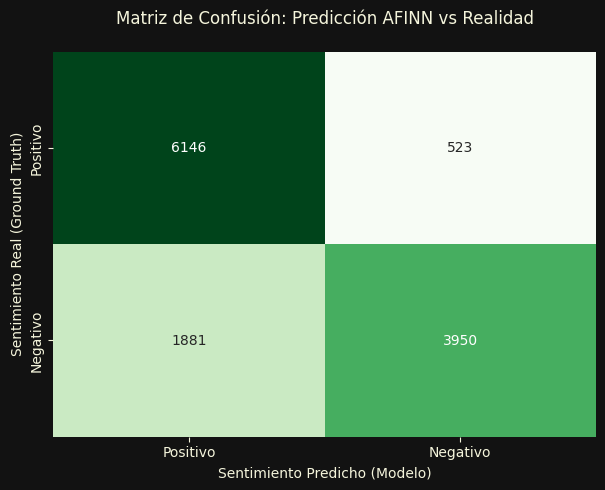

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Descartar las predicciones neutrales de AFINN para la comparativa binaria
df_eval = df_resultados[df_resultados['sentimiento_predicho'] != 'Neutral']

y_real = df_eval['sentimiento_real']
y_pred = df_eval['sentimiento_predicho']

# Cálculo de Accuracy
precision = accuracy_score(y_real, y_pred)
print(f"Precisión del modelo AFINN: {precision * 100:.2f}%\n")

# Matriz de Confusión Visual
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_real, y_pred, labels=['Positivo', 'Negativo'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Positivo', 'Negativo'], 
            yticklabels=['Positivo', 'Negativo'],
            cbar=False)

plt.title('Matriz de Confusión: Predicción AFINN vs Realidad', pad=20)
plt.ylabel('Sentimiento Real (Ground Truth)')
plt.xlabel('Sentimiento Predicho (Modelo)')
plt.show()

In [19]:
df_resultados.head()

,content,score,at,appVersion,texto_limpio,sentimiento_real,sentimiento_predicho
0,It is a good app but it has many bad videos also,1,2024-05-11 10:42:57,NaN,it is a good app but it has many bad videos also,Negativo,Neutral
4,Try Try to and trr Maa ki baat re,4,2024-07-15 14:44:24,441.0.0.32.109,try try to and trr maa ki baat re,Positivo,Neutral
5,It won't even let me log in! It keeps saying s...,1,2024-03-05 15:46:46,453.0.0.40.107,it wont even let me log in it keeps saying ses...,Negativo,Negativo
7,Viral My Reels Please 🥺,5,2024-08-18 12:33:51,477.0.0.56.80,viral my reels please,Positivo,Positivo
8,Ilove you facebook team,5,2024-09-21 08:13:02,481.0.0.61.80,ilove you facebook team,Positivo,Neutral


## Modelado de Tópicos con LSI/SVD
Aplicamos Indexación Semántica Latente (LSI) mediante Descomposición en Valores Singulares (SVD) para descubrir automáticamente los temas latentes en las reseñas negativas. El objetivo es identificar las causas raíz de las quejas de los usuarios.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Filtrar solo las reseñas negativas
df_negativos = df_resultados[df_resultados['sentimiento_predicho'] == 'Negativo'].copy()
df_negativos = df_negativos.dropna(subset=['texto_limpio'])

print(f"Total de reseñas negativas para analizar: {len(df_negativos)}")
print(df_negativos['texto_limpio'].head(3))

Total de reseñas negativas para analizar: 4473
5     it wont even let me log in it keeps saying ses...
18    horrible and quite frankly one of the most inv...
28        s drop me off in a while kipp bio gdp fyi gox
Name: texto_limpio, dtype: object


Convertimos el texto a una matriz numérica usando TF-IDF, que asigna mayor peso a las palabras más relevantes y menos frecuentes. Esta matriz es la entrada para el algoritmo SVD.

In [21]:
# Convertir texto a matriz TF-IDF
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=5,
    max_df=0.85
)

matriz_tfidf = vectorizer.fit_transform(df_negativos['texto_limpio'])
print(f"Dimensiones de la matriz TF-IDF: {matriz_tfidf.shape}")

Dimensiones de la matriz TF-IDF: (4473, 1000)


Aplicamos SVD para reducir la matriz TF-IDF y extraer los temas latentes. Cada tema está representado por las palabras con mayor peso en ese componente.

In [22]:
# Aplicar SVD para extraer 5 temas latentes
NUM_TEMAS = 5

svd = TruncatedSVD(n_components=NUM_TEMAS, random_state=42)
svd.fit(matriz_tfidf)

# Mostrar las palabras principales de cada tema
palabras = vectorizer.get_feature_names_out()

print("=" * 60)
print("TEMAS LATENTES IDENTIFICADOS EN RESEÑAS NEGATIVAS")
print("=" * 60)

for i, componente in enumerate(svd.components_):
    top_palabras = [palabras[j] for j in componente.argsort()[-10:][::-1]]
    print(f"\nTema {i+1}: {' | '.join(top_palabras)}")

TEMAS LATENTES IDENTIFICADOS EN RESEÑAS NEGATIVAS

Tema 1: facebook | app | account | bad | problem | dont | update | working | just | im

Tema 2: bad | app | worst | experience | update | good | application | social | quality | bugs

Tema 3: bad | account | facebook | problem | hacked | experience | login | email | password | team

Tema 4: account | hacked | log | fb | bad | password | im | got | email | reason

Tema 5: app | working | account | problem | log | worst | login | error | phone | open


Varianza explicada por cada componente del SVD: indica qué porcentaje de la información total captura cada tema. Entre mayor sea, más representativo es el tema y más confiable es el análisis.

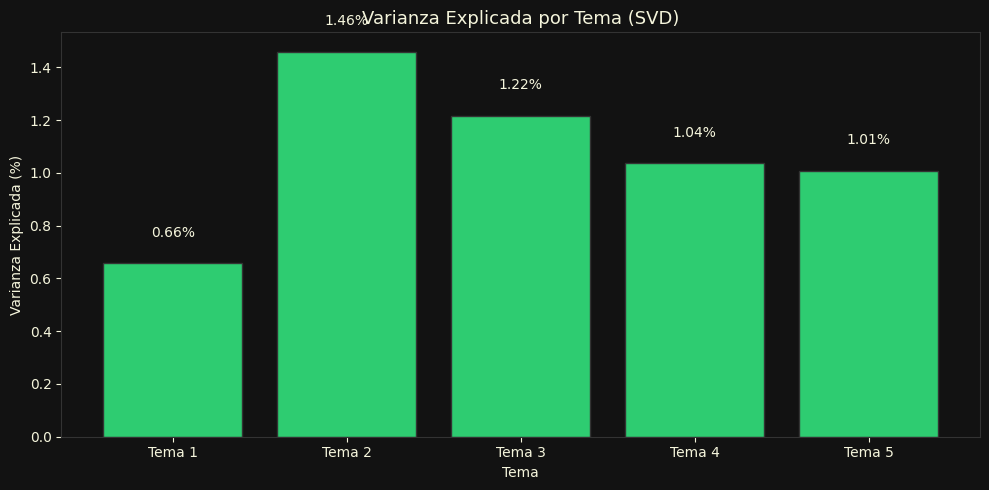


Varianza total explicada por los 5 temas: 5.38%


In [26]:
varianza = svd.explained_variance_ratio_

plt.figure(figsize=(10, 5))
bars = plt.bar([f'Tema {i+1}' for i in range(NUM_TEMAS)], 
               varianza * 100, color='#2ecc71', edgecolor='#333333')
plt.title('Varianza Explicada por Tema (SVD)', color='#f5f5dc', fontsize=13)
plt.xlabel('Tema', color='#f5f5dc')
plt.ylabel('Varianza Explicada (%)', color='#f5f5dc')
plt.gca().set_facecolor('#121212')
plt.gcf().set_facecolor('#121212')
plt.tick_params(colors='#f5f5dc')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333333')
for bar, val in zip(bars, varianza * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', color='#f5f5dc', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nVarianza total explicada por los {NUM_TEMAS} temas: {varianza.sum()*100:.2f}%")

Interpretación de los temas encontrados y visualización de las palabras más relevantes por tema.

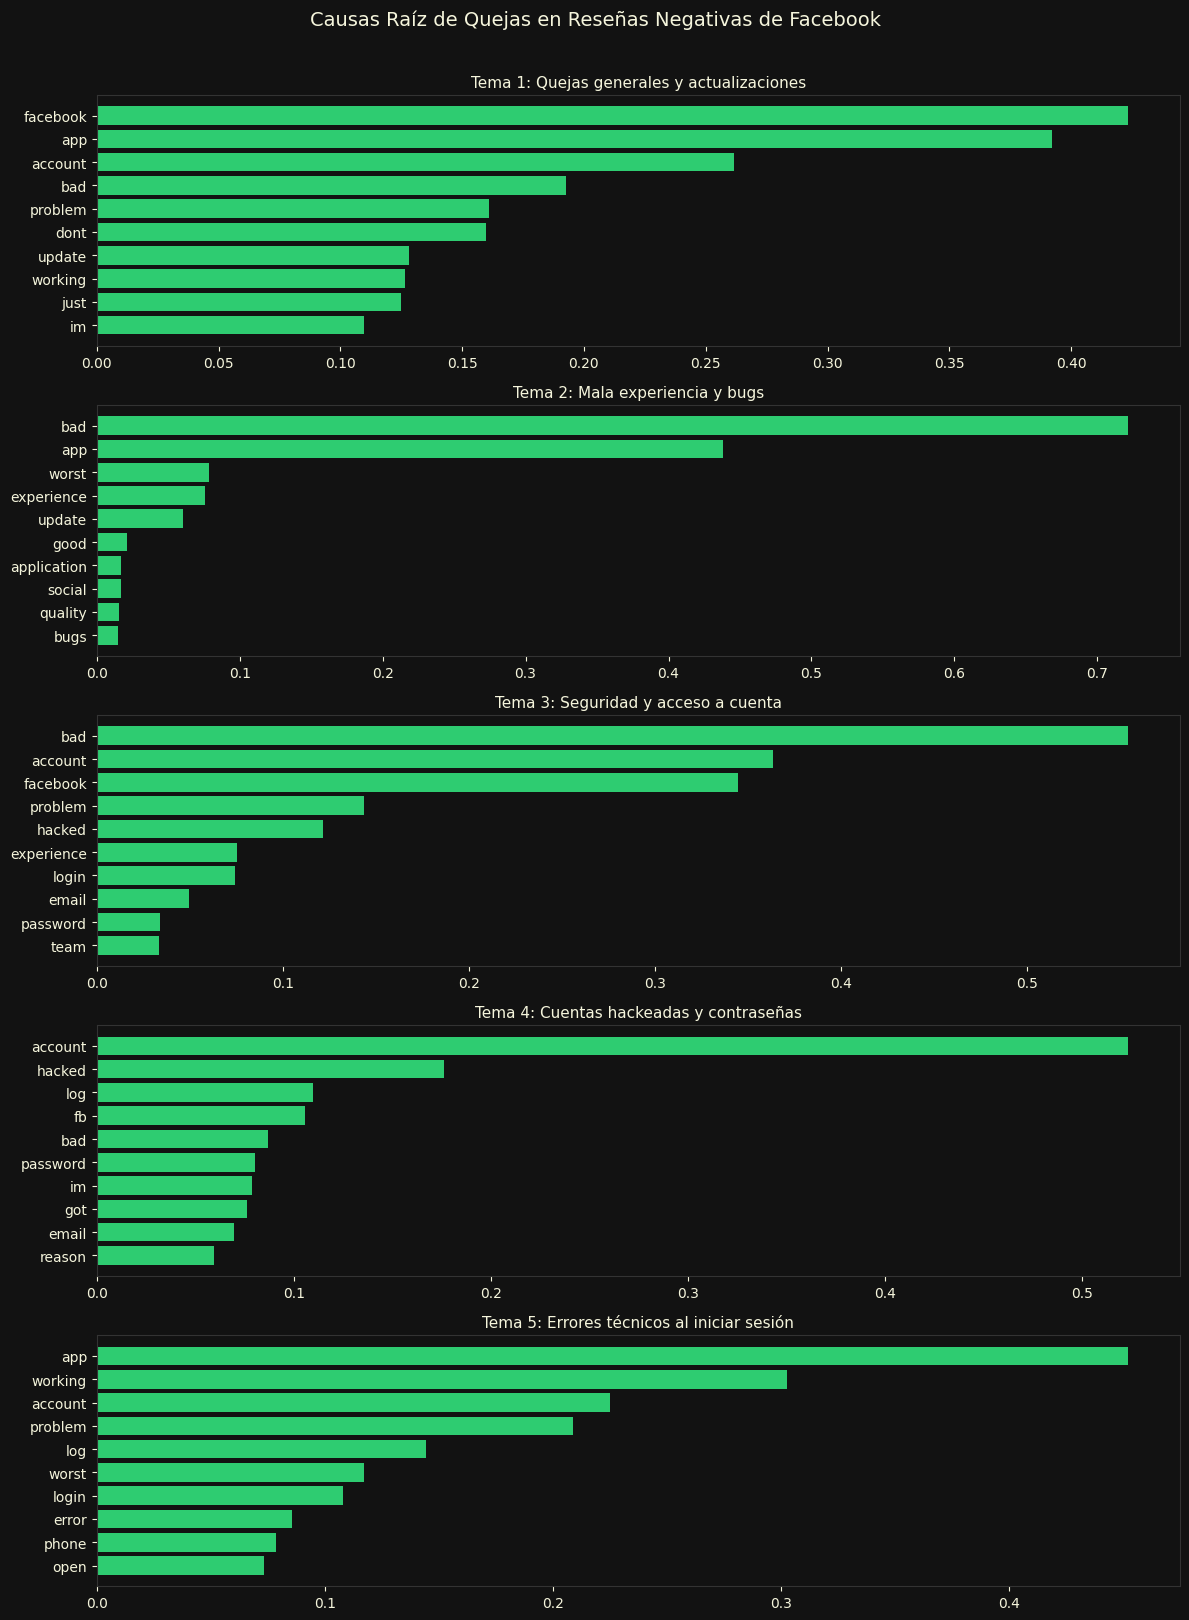

In [23]:
nombres_temas = [
    "Quejas generales y actualizaciones",
    "Mala experiencia y bugs",
    "Seguridad y acceso a cuenta",
    "Cuentas hackeadas y contraseñas",
    "Errores técnicos al iniciar sesión"
]

fig, axes = plt.subplots(NUM_TEMAS, 1, figsize=(12, 16))

for i, (componente, nombre) in enumerate(zip(svd.components_, nombres_temas)):
    top_idx = componente.argsort()[-10:][::-1]
    top_palabras = [palabras[j] for j in top_idx]
    top_valores = [componente[j] for j in top_idx]

    axes[i].barh(top_palabras[::-1], top_valores[::-1], color='#2ecc71')
    axes[i].set_title(f'Tema {i+1}: {nombre}', color='#f5f5dc', fontsize=11)
    axes[i].tick_params(colors='#f5f5dc')
    axes[i].set_facecolor('#121212')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#333333')

fig.patch.set_facecolor('#121212')
plt.suptitle('Causas Raíz de Quejas en Reseñas Negativas de Facebook', 
             color='#f5f5dc', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Distribución de reseñas negativas por tema: calculamos qué tan presente está cada tema en el conjunto de quejas.

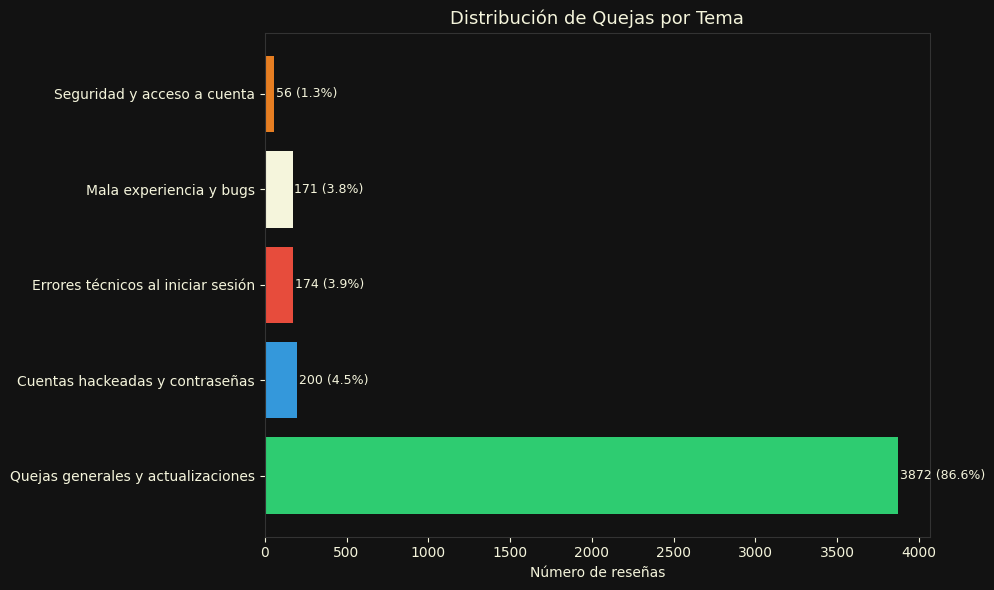

In [24]:
# Calcular qué tema domina en cada reseña negativa
matriz_svd = svd.transform(matriz_tfidf)
tema_dominante = matriz_svd.argmax(axis=1)

df_negativos['tema'] = [nombres_temas[i] for i in tema_dominante]

conteo_temas = df_negativos['tema'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(conteo_temas.index, conteo_temas.values, color=['#2ecc71', '#3498db', '#e74c3c', '#f5f5dc', '#e67e22'])
plt.title('Distribución de Quejas por Tema', color='#f5f5dc', fontsize=13)
plt.xlabel('Número de reseñas', color='#f5f5dc')
plt.gca().set_facecolor('#121212')
plt.gcf().set_facecolor('#121212')
plt.tick_params(colors='#f5f5dc')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333333')
for bar, val in zip(bars, conteo_temas.values):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2, 
             f'{val} ({val/len(df_negativos)*100:.1f}%)', 
             va='center', color='#f5f5dc', fontsize=9)
plt.tight_layout()
plt.show()

Evolución de las quejas en el tiempo: analizamos cómo ha cambiado el volumen de reseñas negativas a lo largo del tiempo para identificar si algún evento o actualización generó un pico de quejas.

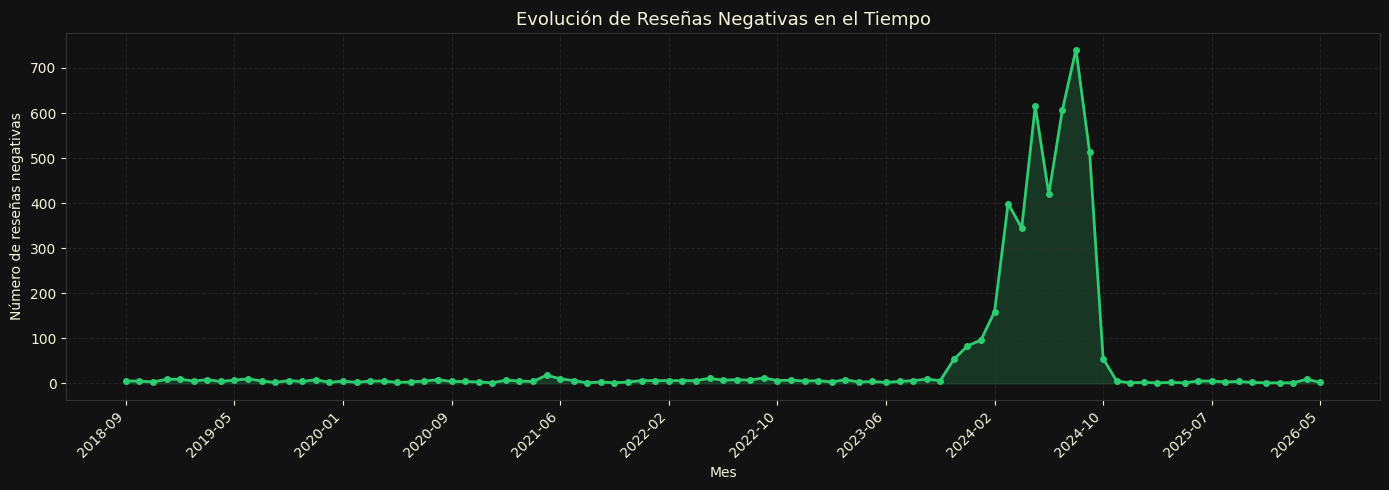

In [28]:
df_negativos['fecha'] = pd.to_datetime(df_negativos['at']).dt.to_period('M')

evolucion = df_negativos.groupby('fecha').size().reset_index(name='cantidad')
evolucion['fecha_str'] = evolucion['fecha'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(evolucion['fecha_str'], evolucion['cantidad'], 
         color='#2ecc71', linewidth=2, marker='o', markersize=4)
plt.fill_between(range(len(evolucion)), evolucion['cantidad'], 
                 alpha=0.2, color='#2ecc71')
plt.title('Evolución de Reseñas Negativas en el Tiempo', color='#f5f5dc', fontsize=13)
plt.xlabel('Mes', color='#f5f5dc')
plt.ylabel('Número de reseñas negativas', color='#f5f5dc')
plt.xticks(range(0, len(evolucion), max(1, len(evolucion)//10)), 
           evolucion['fecha_str'][::max(1, len(evolucion)//10)], 
           rotation=45, ha='right', color='#f5f5dc')
plt.yticks(color='#f5f5dc')
plt.gca().set_facecolor('#121212')
plt.gcf().set_facecolor('#121212')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('#333333')
plt.grid(color='#333333', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Mapa de calor por versión de la app: muestra la intensidad de cada tema de queja según la versión de Facebook. Permite identificar si alguna actualización específica generó más quejas en un tema particular.

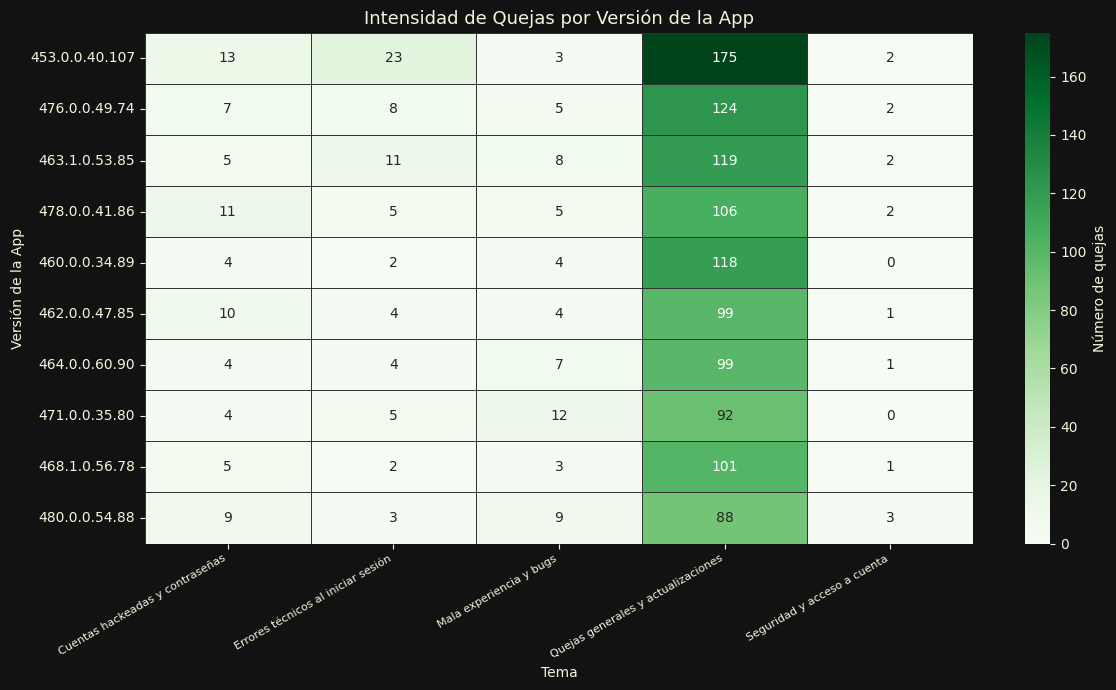

In [29]:
df_heat = df_negativos.dropna(subset=['appVersion'])
df_heat = df_heat.groupby(['appVersion', 'tema']).size().unstack(fill_value=0)

# Quedarse solo con las 10 versiones con más quejas
top_versiones = df_heat.sum(axis=1).nlargest(10).index
df_heat = df_heat.loc[top_versiones]

plt.figure(figsize=(12, 7))
sns.heatmap(df_heat, cmap='Greens', linecolor='#333333', linewidths=0.5,
            annot=True, fmt='d', cbar_kws={'label': 'Número de quejas'})
plt.title('Intensidad de Quejas por Versión de la App', color='#f5f5dc', fontsize=13)
plt.xlabel('Tema', color='#f5f5dc')
plt.ylabel('Versión de la App', color='#f5f5dc')
plt.xticks(rotation=30, ha='right', color='#f5f5dc', fontsize=8)
plt.yticks(color='#f5f5dc')
plt.gca().set_facecolor('#121212')
plt.gcf().set_facecolor('#121212')
plt.tight_layout()
plt.show()

Ejemplos reales por tema: mostramos 2 reseñas representativas de cada tema para validar con evidencia concreta los hallazgos del análisis.

In [30]:
print("=" * 60)
print("EJEMPLOS REALES DE RESEÑAS POR TEMA")
print("=" * 60)

for nombre in nombres_temas:
    ejemplos = df_negativos[df_negativos['tema'] == nombre]['content'].head(2).values
    print(f"\n📌 {nombre}")
    for j, ejemplo in enumerate(ejemplos, 1):
        print(f"  {j}. {str(ejemplo)[:150]}...")
    print("-" * 60)

EJEMPLOS REALES DE RESEÑAS POR TEMA

📌 Quejas generales y actualizaciones
  1. horrible and quite frankly one of the most invasive and malevolent pieces of software applications out there as my tablet was ruthlessly hacked and ca...
  2. S drop me off in a while Kipp bio GDP FYI gox...
------------------------------------------------------------

📌 Mala experiencia y bugs
  1. No bad i like this fb ❤️...
  2. i give bad because there was too much ad and sensitive content also...
------------------------------------------------------------

📌 Seguridad y acceso a cuenta
  1. Customer service is very bad 👎 My account has been locked, I messaged Facebook people to change the option in Gmail but my problem has not been solved...
  2. Facebook sir mera account ban ho gya plz sir account recover kro 🙏🏻🙏🏻🙏🏻😭...
------------------------------------------------------------

📌 Cuentas hackeadas y contraseñas
  1. It sucks!! I've had account hacked twice an when I reported it they told me it didn

Resumen del análisis de tópicos: principales causas raíz identificadas en las reseñas negativas de Facebook.

In [25]:
print("=" * 60)
print("RESUMEN: CAUSAS RAÍZ DE QUEJAS EN FACEBOOK")
print("=" * 60)

for tema, cantidad in conteo_temas.items():
    porcentaje = (cantidad / len(df_negativos)) * 100
    print(f"\n{tema}")
    print(f"  → {cantidad} reseñas ({porcentaje:.1f}%)")

RESUMEN: CAUSAS RAÍZ DE QUEJAS EN FACEBOOK

Quejas generales y actualizaciones
  → 3872 reseñas (86.6%)

Cuentas hackeadas y contraseñas
  → 200 reseñas (4.5%)

Errores técnicos al iniciar sesión
  → 174 reseñas (3.9%)

Mala experiencia y bugs
  → 171 reseñas (3.8%)

Seguridad y acceso a cuenta
  → 56 reseñas (1.3%)
